### 回归 vs 分类

- 回归估计一个连续值
- 分类预测一个离散类别

### 从回归到多类分类

**回归**
- 单连续数值输出
- 自然区间 $\mathbb{R}$
- 跟真实值的区别作为损失

**分类**
- 通常多个输出
- 输出 $i$ 是预测为第 $i$ 类的置信度

### 从回归到多类分类 —— 均方损失

- 对类别进行一位有效编码  
  $$
  \mathbf{y} = [y_1, y_2, \ldots, y_n]^T
  $$
  $$
  y_i = 
  \begin{cases}
    1 & \text{if } i = y \\
    0 & \text{otherwise}
  \end{cases}
  $$
- 使用均方损失训练
- 最大值对应类别为预测  
  $$
  \hat{y} = \arg\max_i o_i
  $$

### 从回归到多类分类 —— 无校验比例

- 对类别进行一位有效编码
- 最大值对应类别为预测  
  $$
  \hat{y} = \arg\max_i o_i
  $$
- 需要更置信地识别正确类（大余量）  
  $$
  o_y - o_i \geq \Delta(y, i)
  $$

### 从回归到多类分类 —— 校验比例

- 输出匹配概率（非负，和为 1）
  $$
  \hat{\mathbf{y}} = \mathrm{softmax}(\mathbf{o})
  $$
  $$
  \hat{y}_i = \frac{\exp(o_i)}{\sum_k \exp(o_k)}
  $$
- 概率 $\mathbf{y}$ 和 $\hat{\mathbf{y}}$ 的区别作为损失

### Softmax 和交叉熵损失

- 交叉熵常用来衡量两个概率的区别  
  $$
  H(\mathbf{p}, \mathbf{q}) = \sum_i -p_i \log(q_i)
  $$
- 将它作为损失  
  $$
  l(\mathbf{y}, \hat{\mathbf{y}}) = -\sum_i y_i \log \hat{y}_i = -\log \hat{y}_y
  $$
- 其梯度是真实概率和预测概率的区别  
  $$
  \partial_{o_i} l(\mathbf{y}, \hat{\mathbf{y}}) = \mathrm{softmax}(\mathbf{o})_i - y_i
  $$

### 总结

- Softmax 回归是一个多类分类模型
- 使用 Softmax 操作子得到每个类的预测置信度
- 使用交叉熵来衡量预测和标号的区别

### 常见的损失函数

#### L2 Loss 均方损失函数 MSE Loss
$$
l(y, y') = \frac{1}{2}(y - y')^2
$$

#### L1 Loss 

$$
l(y, y') = |y - y'|
$$

### Huber 损失

$$
l(y, y') =
\begin{cases}
|y - y'| - \frac{1}{2} & \text{if } |y - y'| > 1 \\\\
\frac{1}{2}(y - y')^2 & \text{otherwise}
\end{cases}
$$

### 图像分类数据集
MNIST数据集是图像分类中广泛使用的数据集之一 
过于简单 使用Fashion-MNIST数据集

In [8]:
import torch
import torchvision
from torch.utils import data
from torchvision import transforms
import matplotlib.pyplot as plt

use_svg_display = True

#### 通过框架中的内置函数将Fashion-MNIST加载到内存中

In [9]:
# 通过ToTensor实例将图像数据从PIL类型变换成32位浮点数格式，并除以255使得所有像素的数值均在0到1之间

trans = transforms.ToTensor()
mnist_train = torchvision.datasets.FashionMNIST(root="../data", train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.FashionMNIST(root="../data", train=False, transform=trans, download=True)
print(len(mnist_train), len(mnist_test))

60000 10000


In [10]:
mnist_train[0][0].shape

torch.Size([1, 28, 28])

In [12]:
def get_fashion_mnist_labels(labels):
    '''返回Fashion-MNIST数据集的文本标签'''
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels]

def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images."""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # 图片张量
            ax.imshow(img.numpy())
        else:
            # PIL图片
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes 

array([<Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 'dress'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 'pullover'}>,
       <Axes: title={'center': 'sneaker'}>,
       <Axes: title={'center': 'pullover'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 'sneaker'}>,
       <Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 'trouser'}>,
       <Axes: title={'center': 't-shirt'}>], dtype=object)

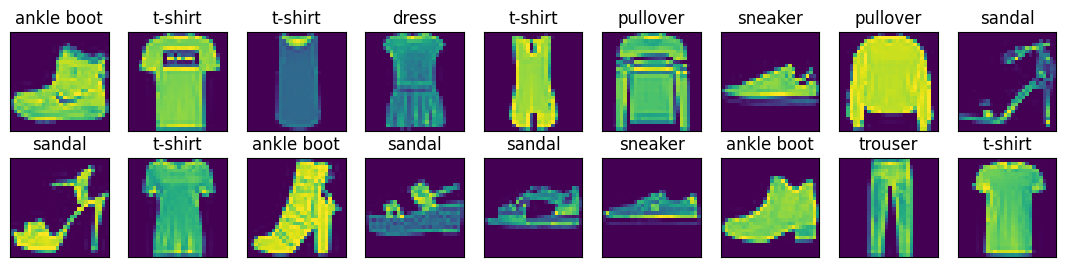

In [20]:
x,y = next(iter(data.DataLoader(mnist_train, batch_size=18)))
show_images(x.reshape(18,28,28), 2, 9, titles=get_fashion_mnist_labels(y))

In [23]:
import time

class Timer:
    def __init__(self):
        self.times = []
        self.start()
    def start(self):
        self.tik = time.time()
    def stop(self):
        self.times.append(time.time() - self.tik)
        return self.times[-1]
    def avg(self):
        return sum(self.times) / len(self.times)
    def sum(self):
        return sum(self.times)
    def cumsum(self):
        return np.array(self.times).cumsum().tolist()

batch_size = 256

def get_dataloader_workers():
    """Use 4 processes to read the data."""
    return 0

train_iter = data.DataLoader(mnist_train, batch_size, shuffle=True, num_workers=get_dataloader_workers())

timer = Timer()

for x , y in train_iter:
    continue
print(f'{timer.stop():.2f} sec')

2.18 sec


### 定义Load_data_fashion_mnist函数

In [24]:
def load_data_fashion_mnist(batch_size, resize=None):
    """Download the Fashion-MNIST dataset and then load it into memory."""
    transs = [transforms.ToTensor()]
    if resize:
        transs.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(transs)
    mnist_train = torchvision.datasets.FashionMNIST(root="../data", train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.FashionMNIST(root="../data", train=False, transform=trans, download=True)

    return (data.DataLoader(mnist_train, batch_size, shuffle=True, num_workers=get_dataloader_workers()),
            data.DataLoader(mnist_test, batch_size, shuffle=False, num_workers=get_dataloader_workers()))
    
train_iter, test_iter = load_data_fashion_mnist(batch_size)
for x, y in train_iter:
    print(x.shape, y.shape)
    break


torch.Size([256, 1, 28, 28]) torch.Size([256])


### softmax回归的从零开始实现

In [27]:
import torch
import IPython
import IPython.display as display

batch_size = 256
train_iter, test_iter = load_data_fashion_mnist(batch_size)
timer = Timer()

In [28]:
num_inputs = 784
num_outputs = 10

w = torch.normal(0, 0.01, size=(num_inputs, num_outputs), requires_grad=True)
b = torch.zeros(num_outputs, requires_grad=True) 

#### 给定一个矩阵X，我们可以对所有元素求和

In [29]:
X = torch.tensor([[1.0, 2.0,3.0],[4.0,5.0,6.0]])
X.sum(0,keepdim = True), X.sum(1,keepdim=True)

(tensor([[5., 7., 9.]]),
 tensor([[ 6.],
         [15.]]))

#### 实现softmax

$$
\mathrm{softmax}(\mathbf{X})_{ij} = \frac{\exp(\mathbf{X}_{ij})}{\sum_k \exp(\mathbf{X}_{ik})}
$$

In [30]:
def softmax(X):
    X_exp = torch.exp(X)
    partition = X_exp.sum(1,keepdim = True)
    return X_exp / partition  # 这里应用了广播机制

#### 我们将每个元素变成一个非负数。此外，依据概率原理，每行总和为1

In [31]:
X = torch.normal(0, 1, (2, 5))
X_prob = softmax(X)
X_prob, X_prob.sum(1)

(tensor([[0.1141, 0.1014, 0.4904, 0.1890, 0.1052],
         [0.1874, 0.3704, 0.2426, 0.0789, 0.1207]]),
 tensor([1.0000, 1.0000]))

#### 实现softmax回归模型

In [32]:
def net(X):
    return softmax(torch.matmul(X.reshape((-1,w.shape[0])) , w) + b)

#### 创建一个数据y_hat，其中包含2个样本在3个类别的预测概率，使用y作为y_hat中的索引

In [33]:
y = torch.tensor([0, 2])
y_hat = torch.tensor([[0.1, 0.3, 0.6], [0.3, 0.2, 0.5]])
y_hat[[0,1],y]

tensor([0.1000, 0.5000])

#### 实现交叉熵损失函数

In [34]:
def cross_entropy(y_hat, y):
    return - torch.log(y_hat[range(len(y_hat)), y])
cross_entropy(y_hat, y)

tensor([2.3026, 0.6931])

#### 将预测类别与真实元素y进行比较

In [37]:
def accuracy(y_hat, y):
    """计算预测正确的数量"""
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

accuracy(y_hat, y)/len(y)

0.5

#### 我们可以评估在任意模型net的准确率

In [44]:
def evaluate_accuracy(net, data_iter):
    """计算在指定数据集上模型的精度"""
    if isinstance(net, torch.nn.Module):
        net.eval()  # 将模型设置为评估模式
    metric = Accumulator(2)  # 正确预测数、预测总数
    with torch.no_grad():
        for X, y in data_iter:
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

In [45]:
class Accumulator:
    """在n个变量上累加"""
    def __init__(self, n):
        self.data = [0.0] * n
    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]
    def reset(self):
        self.data = [0.0] * len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]
evaluate_accuracy(net, test_iter)

0.1297

#### Softmax回归的训练


In [ ]:
def train_epoch_ch3(net, train_iter, loss, updater):
    """训练模型一个迭代周期"""
    # 将net设置为训练模式
    if isinstance(net, torch.nn.Module):
        net.train()
    # 训练损失总和，训练准确度总和，样本数
    metric = Accumulator(3)
    for X, y in train_iter:
        # 计算梯度并更新参数
        y_hat = net(X)
        l = loss(y_hat, y)
        if isinstance(updater, torch.optim.Optimizer):
            # 使用PyTorch内置的优化器和损失函数
            updater.zero_grad()
            l.mean().backward()
            updater.step()
        else:
            # 使用定制的优化器和损失函数
            l.sum().backward()
            updater(X.shape[0])
        metric.add(float(l.sum()), accuracy(y_hat, y), y.numel())
    # 返回训练损失和训练精度
    return metric[0] / metric[2], metric[1] / metric[2]

#### 定义一个在动画中绘制数据的使用程序类

In [60]:
class Animator:
    """在动画中绘制数据"""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear', fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1, figsize=(3.5,2.5)):
        
        if legend is None:
            legend = []
        self.fig, self.axes = plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes,]
        # 使用lambda函数捕获参数
        self.config_axes = lambda: self.set_axes(self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        """添加数据点"""
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if self.X is None:
            self.X = [[] for _ in range(n)]
        if self.Y is None:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()

    def set_axes(self, axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
        axes.set_xlabel(xlabel)
        axes.set_ylabel(ylabel)
        axes.set_xlim(xlim)
        axes.set_ylim(ylim)
        axes.set_xscale(xscale)
        axes.set_yscale(yscale)
        if legend:
            axes.legend(legend)
        axes.grid()
   

#### 训练函数

In [61]:
def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater):
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0.3, 0.9], legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        train_metrics = train_epoch_ch3(net, train_iter, loss, updater)
        test_acc = evaluate_accuracy(net, test_iter)
        animator.add(epoch + 1, train_metrics + (test_acc,))

    train_loss, train_acc = train_metrics

#### 小批量随机梯度下降来优化模型的损失函数

In [62]:
lr = 0.1

def sgd(params, lr, batch_size):
    """小批量随机梯度下降"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

def updater(batch_size):
    return sgd([w, b], lr, batch_size)

#### 训练模型迭代十个周期

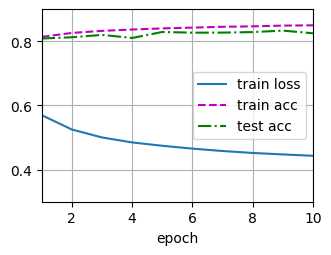

In [63]:
num_epochs = 10
train_ch3(net, train_iter, test_iter, cross_entropy, num_epochs, updater)

#### 对图像进行分类预测

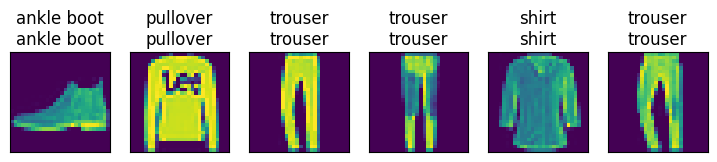

In [65]:
def predict_ch3(net, test_iter, n=6):
    """预测标签"""
    for X, y in test_iter:
        break
    trues = get_fashion_mnist_labels(y)
    preds = get_fashion_mnist_labels(net(X).argmax(axis=1))
    titles = [true + '\n' + pred for true, pred in zip(trues, preds)]
    show_images(X[0:n].reshape((n, 28, 28)), 1, n, titles=titles[0:n])

predict_ch3(net, test_iter)

### softmax回归的简洁实现

In [66]:
import torch
from torch import nn

batch_size = 256
train_iter, test_iter = load_data_fashion_mnist(batch_size)

#### Softmax回归的输出层是一个全连接层

In [ ]:
#PyTorch不会隐式调整输入的形状，因此我们需要在定义模型时展平每个图像
net = nn.Sequential(nn.Flatten(), nn.Linear(784, 10))

def init_weights(m): 
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=10, bias=True)
)

#### 在交叉熵损失函数中传递未归一化的预测，并同时计算softmax及其对数

In [68]:
loss = nn.CrossEntropyLoss()

#### 使用学习率为0.1的小批量随机梯度下降作为优化算法

In [69]:
trainer = torch.optim.SGD(net.parameters(), lr=0.1)

#### 调用之前定义的训练函数来训练模型

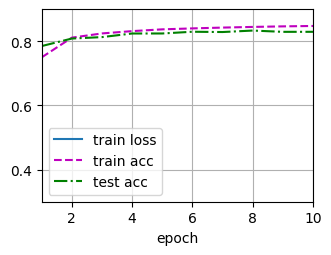

In [70]:
num_epochs = 10
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)